# Predictive Maintenance — EDA & Feature Engineering (EDA & Feature Engineering)
### Project: Industrial Predictive Maintenance & Failure Prevention
### Dataset: AI4I 2020 Predictive Maintenance Dataset (UCI), `ai4i2020.csv`

**Scope of this notebook (EDA & Feature Engineering):**
- Raw data inspection & data dictionary
- Comprehensive EDA (univariate, bivariate, target, failure-mode)
- Data leakage analysis
- Temporal-structure assessment
- Feature engineering
- Feature selection & statistical analysis
- ML-ready pipeline definition (no leakage across the train/val/test split)

**Important caveat (per project rules):** AI4I 2020 is a **synthetic benchmark
dataset**. Nothing in this notebook should be read as a claim about real
industrial machine reliability — it is a methodology exercise on a synthetic,
well-studied benchmark.

This notebook works from the raw CSV independently of Data Engineering's SQL/ETL work,
per the parallel-work instruction. Findings that affect cleaning / schema
design are called out explicitly for Data Engineering in the final section.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42


In [4]:
df_raw = pd.read_csv("../data/ai4i2020_raw.csv")
print(f"Loaded ai4i2020.csv -> shape: {df_raw.shape}")
df_raw.head()

Loaded ai4i2020.csv -> shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1. Raw Dataset Inspection

We inspect the dataset without assuming any column meaning in advance —
everything below is derived from the actual data.

In [5]:
print("Shape (rows, cols):", df_raw.shape)
print()
print("Columns:", list(df_raw.columns))
print()
print("Dtypes:")
print(df_raw.dtypes)


Shape (rows, cols): (10000, 14)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Dtypes:
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [6]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(3)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].empty
print("Any missing values across the dataset?", df_raw.isnull().values.any())
missing_summary


Any missing values across the dataset? False


,missing_count,missing_pct
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


In [7]:
dupe_full = df_raw.duplicated().sum()
dupe_no_id = df_raw.drop(columns=['UDI', 'Product ID']).duplicated().sum()
print(f"Fully duplicated rows: {dupe_full}")
print(f"Duplicated rows ignoring UDI/Product ID (identical sensor+outcome profile): {dupe_no_id}")


Fully duplicated rows: 0
Duplicated rows ignoring UDI/Product ID (identical sensor+outcome profile): 0


In [8]:
print("UDI: min={}, max={}, n_unique={}, n_rows={}".format(
    df_raw['UDI'].min(), df_raw['UDI'].max(), df_raw['UDI'].nunique(), len(df_raw)))
print("-> UDI is a simple 1..N row index, one row per UDI (no repeats).")
print()
print("Product ID: n_unique={}, n_rows={}".format(df_raw['Product ID'].nunique(), len(df_raw)))
print("-> Every Product ID is unique: each row is a DIFFERENT physical product/unit,")
print("   not repeated observations of the same machine over time.")
print()
print("Type value counts:")
print(df_raw['Type'].value_counts())
print()
# Confirm Product ID prefix letter matches Type (L/M/H quality variants)
prefix_match = (df_raw['Product ID'].str[0] == df_raw['Type']).mean()
print(f"Product ID first letter matches Type column for {prefix_match:.1%} of rows")


UDI: min=1, max=10000, n_unique=10000, n_rows=10000
-> UDI is a simple 1..N row index, one row per UDI (no repeats).

Product ID: n_unique=10000, n_rows=10000
-> Every Product ID is unique: each row is a DIFFERENT physical product/unit,
   not repeated observations of the same machine over time.

Type value counts:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Product ID first letter matches Type column for 100.0% of rows


In [9]:
binary_cols = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
for c in binary_cols:
    print(c, '->', sorted(df_raw[c].unique()))


Machine failure -> [np.int64(0), np.int64(1)]
TWF -> [np.int64(0), np.int64(1)]
HDF -> [np.int64(0), np.int64(1)]
PWF -> [np.int64(0), np.int64(1)]
OSF -> [np.int64(0), np.int64(1)]
RNF -> [np.int64(0), np.int64(1)]


In [10]:
df_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


### 1.1 What the raw inspection tells us

- **10,000 rows, 14 columns, zero missing values, zero exact duplicate rows.**
  This is expected — AI4I 2020 is a cleaned, synthetic benchmark, not raw
  sensor telemetry, so we should not expect the kind of messiness (missing
  sensor pings, sensor drift, duplicate logs) that a real plant would produce.
- **`UDI`** is a plain 1..10000 row index — not a timestamp, not a machine ID.
- **`Product ID`** is unique per row (e.g. `M14860`, `L47181`). It is **not**
  a repeated machine identifier — every row represents a distinct product
  unit. The leading letter (`L`/`M`/`H`) encodes the product quality
  variant and matches the `Type` column exactly.
- **`Type`** is categorical with 3 levels: `L` (low quality, ~60%),
  `M` (medium, ~30%), `H` (high, ~10%) — a plausible product-mix skew.
- Six binary 0/1 columns: **`Machine failure`** (overall target) and five
  **failure-mode indicator columns**: `TWF`, `HDF`, `PWF`, `OSF`, `RNF`.
- Five continuous/near-continuous numeric sensor/process columns: air
  temperature, process temperature, rotational speed, torque, tool wear.

We build the full data dictionary next.

## 2. Data Dictionary

Built from the actual column contents inspected above (not assumed).

| Column | Meaning | Data Type | Role | Notes |
|---|---|---|---|---|
| `UDI` | Unique row index (1–10000) | int | Identifier | Not a timestamp; sequential row number only |
| `Product ID` | Unique product/unit serial (letter prefix + digits) | string | Identifier | 100% unique — one row per physical unit, not repeated machine readings |
| `Type` | Product quality variant: L (low), M (medium), H (high) | categorical | Feature | Matches `Product ID` prefix letter exactly; proxy for product-line/quality tier |
| `Air temperature [K]` | Ambient air temperature around the machine, Kelvin | float | Feature | Process-condition sensor reading |
| `Process temperature [K]` | Temperature of the process/tooling, Kelvin | float | Feature | Strongly related to air temperature (see correlation analysis) |
| `Rotational speed [rpm]` | Spindle/tool rotational speed | int | Feature | Process-condition sensor reading |
| `Torque [Nm]` | Torque applied during the process | float | Feature | Process-condition sensor reading |
| `Tool wear [min]` | Cumulative tool wear time in minutes | int | Feature | Available before failure — accumulates over the tool's life |
| `Machine failure` | Overall binary machine-failure indicator (1 = failed) | int (0/1) | **Primary target** | Equal to 1 if the machine failed for *any* reason; used for the main classification task |
| `TWF` | Tool Wear Failure indicator | int (0/1) | Failure-mode sub-label | 1 of 5 specific failure-mode flags; see leakage analysis |
| `HDF` | Heat Dissipation Failure indicator | int (0/1) | Failure-mode sub-label | " |
| `PWF` | Power Failure indicator | int (0/1) | Failure-mode sub-label | " |
| `OSF` | Overstrain Failure indicator | int (0/1) | Failure-mode sub-label | " |
| `RNF` | Random Failure indicator (failure with no identifiable process cause) | int (0/1) | Failure-mode sub-label | " |

**Role classification for ML purposes** (elaborated in the leakage section):
- **Features (safe, pre-failure information):** `Type`, `Air temperature [K]`,
  `Process temperature [K]`, `Rotational speed [rpm]`, `Torque [Nm]`,
  `Tool wear [min]`.
- **Primary target:** `Machine failure`.
- **Leakage risk / excluded from the feature set for the primary task:**
  `TWF`, `HDF`, `PWF`, `OSF`, `RNF` — these are outcome labels that
  *explain* the failure post hoc (which failure mechanism fired), not
  sensor conditions available beforehand. They are retained only for
  failure-mode analysis, not as predictors of `Machine failure`.
- **Identifiers, not model features:** `UDI`, `Product ID`.


## 3. Univariate Analysis

### 3.A Numerical variables

In [11]:
num_cols = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

stats_table = df_raw[num_cols].agg(['mean', 'median', 'std', 'min', 'max']).T
stats_table['IQR'] = df_raw[num_cols].quantile(0.75) - df_raw[num_cols].quantile(0.25)
stats_table.round(3)


,mean,median,std,min,max,IQR
Air temperature [K],300.005,300.1,2.000,295.3,304.5,3.2
Process temperature [K],310.006,310.1,1.484,305.7,313.8,2.3
Rotational speed [rpm],1538.776,1503.0,179.284,1168.0,2886.0,189.0
Torque [Nm],39.987,40.1,9.969,3.8,76.6,13.6
Tool wear [min],107.951,108.0,63.654,0.0,253.0,109.0


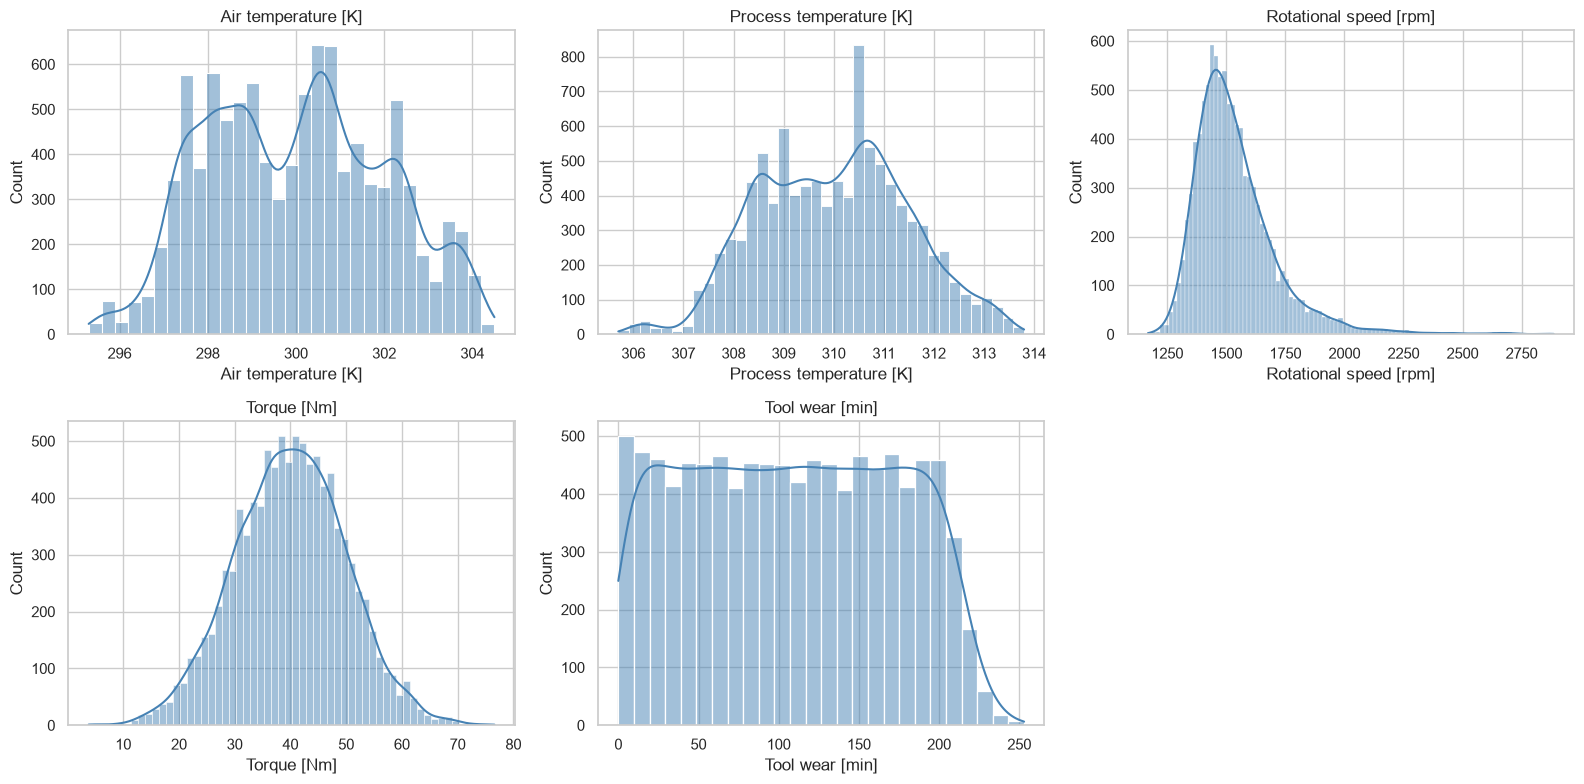

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, c in enumerate(num_cols):
    sns.histplot(df_raw[c], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(c)
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('../reports/figures/univariate_histograms.png', dpi=110)
plt.show()


In [14]:
# Outlier scan via IQR rule (does not remove anything -- just reports counts)
outlier_report = {}
for c in num_cols:
    q1, q3 = df_raw[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_raw[c] < lo) | (df_raw[c] > hi)).sum()
    outlier_report[c] = {'lower_bound': round(lo, 2), 'upper_bound': round(hi, 2),
                          'n_outliers_iqr': n_out, 'pct_outliers': round(n_out / len(df_raw) * 100, 2)}
pd.DataFrame(outlier_report).T


,lower_bound,upper_bound,n_outliers_iqr,pct_outliers
Air temperature [K],293.50,306.30,0.0,0.00
Process temperature [K],305.35,314.55,0.0,0.00
Rotational speed [rpm],1139.50,1895.50,418.0,4.18
Torque [Nm],12.80,67.20,69.0,0.69
Tool wear [min],-110.50,325.50,0.0,0.00


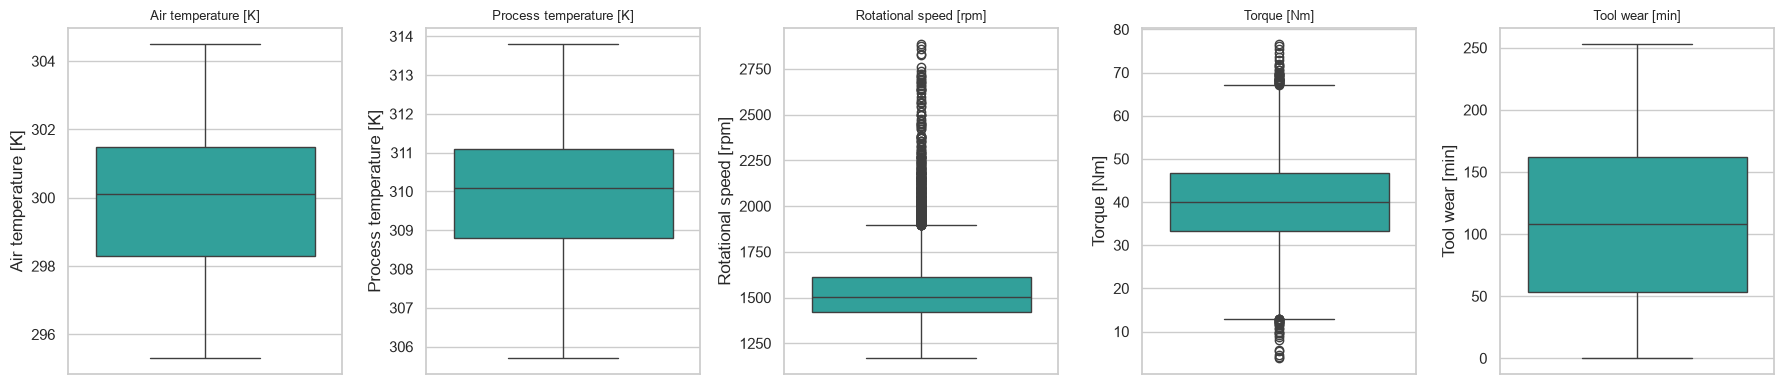

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, c in enumerate(num_cols):
    sns.boxplot(y=df_raw[c], ax=axes[i], color='lightseagreen')
    axes[i].set_title(c, fontsize=9)
plt.tight_layout()
plt.show()


**Observations:**
- `Air temperature [K]` and `Process temperature [K]` are both roughly
  bell-shaped, centered near 300K, with process temperature running
  consistently a few Kelvin above air temperature.
- `Rotational speed [rpm]` is right-skewed with a long tail toward high
  RPM — the IQR rule flags a non-trivial fraction of "outliers" here, but
  given the skew this looks like a genuine (if synthetic) operating-regime
  tail rather than a data-entry error, so nothing is removed at this stage.
- `Torque [Nm]` is roughly symmetric/bell-shaped around ~40 Nm, with a few
  IQR outliers at both tails.
- `Tool wear [min]` looks close to a uniform distribution from 0 to ~250
  minutes, consistent with a synthetic tool-wear counter, not a real
  degradation-then-reset process. No IQR outliers, as expected for a
  near-uniform variable.
- None of these look like data-quality artifacts (no impossible negative
  values, no obviously miscoded sentinel values e.g. -999). We do **not**
  remove any rows at the univariate-outlier stage — see Section 7 for how
  outliers/extremes are actually treated relative to the failure target.

### 3.B Categorical / binary variables

In [16]:
cat_cols = ['Type']
binary_cols = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

for c in cat_cols + binary_cols:
    vc = df_raw[c].value_counts()
    pct = (vc / len(df_raw) * 100).round(2)
    print(f"--- {c} ---")
    print(pd.DataFrame({'count': vc, 'pct': pct}))
    print()


--- Type ---
      count    pct
Type              
L      6000  60.00
M      2997  29.97
H      1003  10.03

--- Machine failure ---
                 count    pct
Machine failure              
0                 9661  96.61
1                  339   3.39

--- TWF ---
     count    pct
TWF              
0     9954  99.54
1       46   0.46

--- HDF ---
     count    pct
HDF              
0     9885  98.85
1      115   1.15

--- PWF ---
     count    pct
PWF              
0     9905  99.05
1       95   0.95

--- OSF ---
     count    pct
OSF              
0     9902  99.02
1       98   0.98

--- RNF ---
     count    pct
RNF              
0     9981  99.81
1       19   0.19



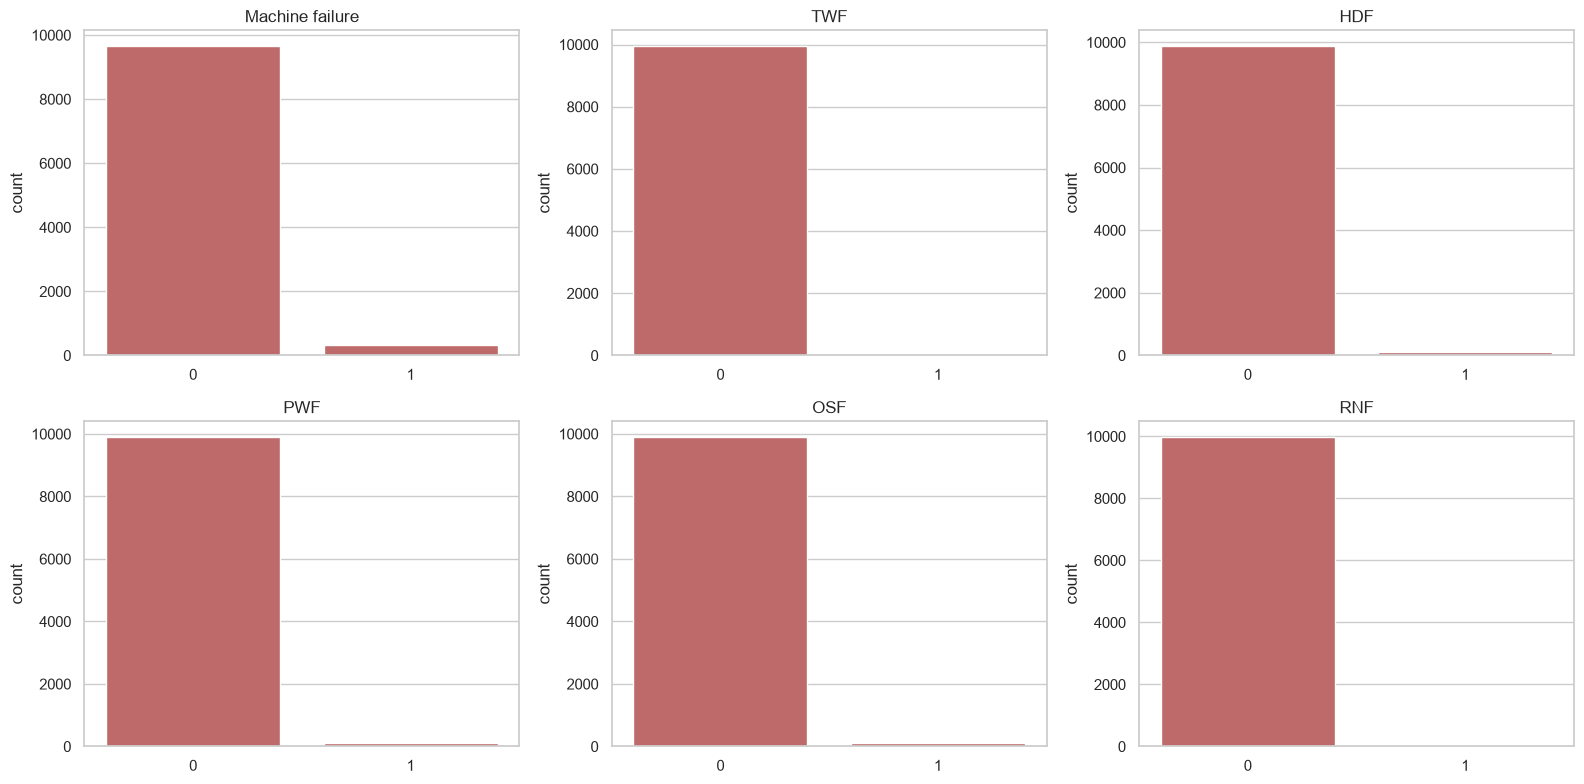

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, c in enumerate(binary_cols):
    sns.countplot(x=df_raw[c], ax=axes[i], color='indianred')
    axes[i].set_title(c)
    axes[i].set_xlabel('')
plt.tight_layout()
plt.savefig('../reports/figures/binary_countplots.png', dpi=110)
plt.show()


**Observations:**
- `Type`: `L` ≈ 60%, `M` ≈ 30%, `H` ≈ 10% — an imbalanced but plausible
  product-mix split, not a data problem.
- Every binary failure-mode column (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) and
  the overall `Machine failure` target are **heavily imbalanced toward 0**
  — this is expected for real (and realistically-simulated) failure data
  and is examined in detail in Section 4.

## 4. Target Analysis — `Machine failure`

In [18]:
n_total = len(df_raw)
n_fail = df_raw['Machine failure'].sum()
n_normal = n_total - n_fail
fail_pct = n_fail / n_total * 100

print(f"Total machines/observations: {n_total}")
print(f"Normal (0): {n_normal}  ({100 - fail_pct:.2f}%)")
print(f"Failure (1): {n_fail}  ({fail_pct:.2f}%)")
print(f"Imbalance ratio (normal:failure): {n_normal / n_fail:.1f} : 1")


Total machines/observations: 10000
Normal (0): 9661  (96.61%)
Failure (1): 339  (3.39%)
Imbalance ratio (normal:failure): 28.5 : 1


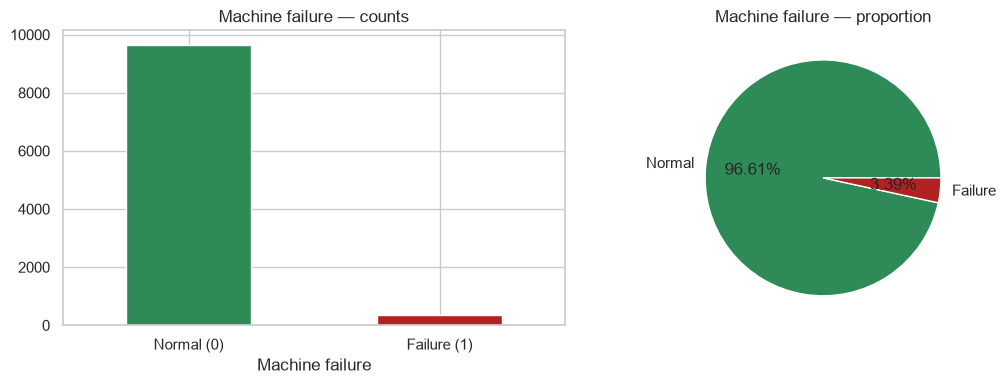

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df_raw['Machine failure'].value_counts().plot.bar(ax=ax[0], color=['seagreen', 'firebrick'])
ax[0].set_title('Machine failure — counts')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['Normal (0)', 'Failure (1)'], rotation=0)

df_raw['Machine failure'].value_counts(normalize=True).plot.pie(
    ax=ax[1], autopct='%1.2f%%', colors=['seagreen', 'firebrick'],
    labels=['Normal', 'Failure'])
ax[1].set_ylabel('')
ax[1].set_title('Machine failure — proportion')
plt.tight_layout()
plt.show()


### Why class imbalance matters here

Only **~3.4%** of machines are labeled as failures. This has direct
consequences for how we must evaluate any model built later in the project:

- **Accuracy is misleading.** A trivial model that always predicts
  "no failure" would score **~96.6% accuracy** while catching **zero**
  real failures — accuracy alone would make a useless model look good.
- **False negatives are the costly error class** for predictive
  maintenance (missing a real failure means unplanned downtime, safety
  risk, or equipment damage), which is exactly why the project brief
  prioritizes **recall, PR-AUC, F1, and false-negative rate** over
  accuracy.
- **PR-AUC (precision–recall AUC) is more informative than ROC-AUC**
  under heavy imbalance, because ROC-AUC can look deceptively good even
  when precision on the rare positive class is poor.
- Downstream (Classical ML/Deep Learning) will likely need imbalance-handling strategies
  (class weighting, resampling, threshold tuning, focal loss, etc.) —
  noted in the handoff document.
- **Leakage risk compounds with imbalance**: because failures are rare,
  a leaky feature that "predicts" them almost perfectly is very tempting
  to keep and very easy to miss during a quick pass — this is why
  Section 6 (leakage) is treated as a mandatory gate before modeling.

## 5. Failure-Mode Analysis

The dataset provides five specific failure-mode indicator columns in
addition to the overall `Machine failure` target:
`TWF` (Tool Wear Failure), `HDF` (Heat Dissipation Failure),
`PWF` (Power Failure), `OSF` (Overstrain Failure), `RNF` (Random Failure).

In [20]:
fail_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
mode_counts = df_raw[fail_modes].sum().sort_values(ascending=False)
mode_pct_of_all = (mode_counts / n_total * 100).round(3)
mode_pct_of_failures = (mode_counts / n_fail * 100).round(2)

mode_summary = pd.DataFrame({
    'count': mode_counts,
    'pct_of_all_rows': mode_pct_of_all,
    'pct_of_failure_rows': mode_pct_of_failures
})
mode_summary


,count,pct_of_all_rows,pct_of_failure_rows
HDF,115,1.15,33.92
OSF,98,0.98,28.91
PWF,95,0.95,28.02
TWF,46,0.46,13.57
RNF,19,0.19,5.60


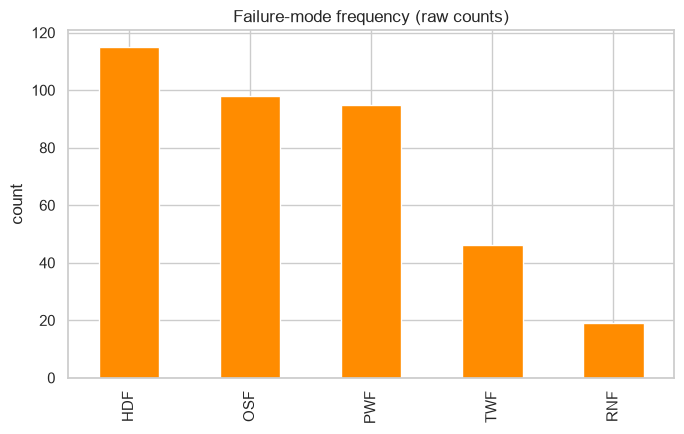

In [21]:
fig, ax = plt.subplots(figsize=(7, 4.5))
mode_counts.plot.bar(ax=ax, color='darkorange')
ax.set_title('Failure-mode frequency (raw counts)')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()


In [22]:
# Consistency check between overall target and mode flags
any_mode_flagged = df_raw[fail_modes].sum(axis=1) > 0
n_modes_flagged = df_raw[fail_modes].sum(axis=1)

fail_no_mode = ((df_raw['Machine failure'] == 1) & (~any_mode_flagged)).sum()
mode_no_fail = ((df_raw['Machine failure'] == 0) & (any_mode_flagged)).sum()
multi_mode = (n_modes_flagged > 1).sum()

print(f"Rows where Machine failure=1 but NO mode flag is set: {fail_no_mode}")
print(f"Rows where Machine failure=0 but a mode flag IS set: {mode_no_fail}")
print(f"Rows where MORE THAN ONE mode flag is set simultaneously: {multi_mode}")
print()
print("Example rows, failure=1 with no mode flagged:")
display_cols = ['UDI', 'Type', 'Machine failure'] + fail_modes
print(df_raw.loc[(df_raw['Machine failure'] == 1) & (~any_mode_flagged), display_cols].head(10))
print()
print("Example rows, failure=0 with a mode flagged:")
print(df_raw.loc[(df_raw['Machine failure'] == 0) & (any_mode_flagged), display_cols].head(10))


Rows where Machine failure=1 but NO mode flag is set: 9
Rows where Machine failure=0 but a mode flag IS set: 18
Rows where MORE THAN ONE mode flag is set simultaneously: 24

Example rows, failure=1 with no mode flagged:
       UDI Type  Machine failure  TWF  HDF  PWF  OSF  RNF
1437  1438    H                1    0    0    0    0    0
2749  2750    M                1    0    0    0    0    0
4044  4045    M                1    0    0    0    0    0
4684  4685    M                1    0    0    0    0    0
5536  5537    M                1    0    0    0    0    0
5941  5942    L                1    0    0    0    0    0
6478  6479    L                1    0    0    0    0    0
8506  8507    L                1    0    0    0    0    0
9015  9016    L                1    0    0    0    0    0

Example rows, failure=0 with a mode flagged:
       UDI Type  Machine failure  TWF  HDF  PWF  OSF  RNF
1221  1222    M                0    0    0    0    0    1
1302  1303    L                0    0 

**Key findings — failure modes:**

- All five failure modes are **rare individually** (from `TWF` at ~0.5% of
  all rows up to `HDF` at ~1.2%), consistent with `Machine failure` itself
  being rare overall.
- The mode flags are **mostly, but not perfectly, consistent** with the
  overall `Machine failure` label: a small number of rows have
  `Machine failure = 1` with no mode flagged, and a small number have
  `Machine failure = 0` while a mode flag is set. This is a **documented
  quirk of the original AI4I 2020 dataset** (the authors note the labeling
  logic isn't a perfectly deterministic OR of the five flags). We treat
  `Machine failure` as the authoritative target and do not attempt to
  "correct" it from the mode flags, since we have no ground truth for
  which is right — we simply document the inconsistency.
- A small number of rows have **more than one failure mode flagged at
  once**, i.e. failures are not always mutually exclusive by mechanism.
- **Critical distinction for leakage:** the failure-mode columns describe
  *why* a machine failed — that information is only knowable **after**
  the failure occurred (or after root-cause analysis). It is **not**
  available at prediction time and must not be used as an input feature
  when predicting `Machine failure` itself (elaborated in Section 6).

### 5.1 Which sensor/process variables associate with which failure mode?

This is purely descriptive/diagnostic (to understand the synthetic
generative logic of the dataset) — it is **not** feature engineering for
the primary predictive task, since the mode columns themselves are
post-failure information.

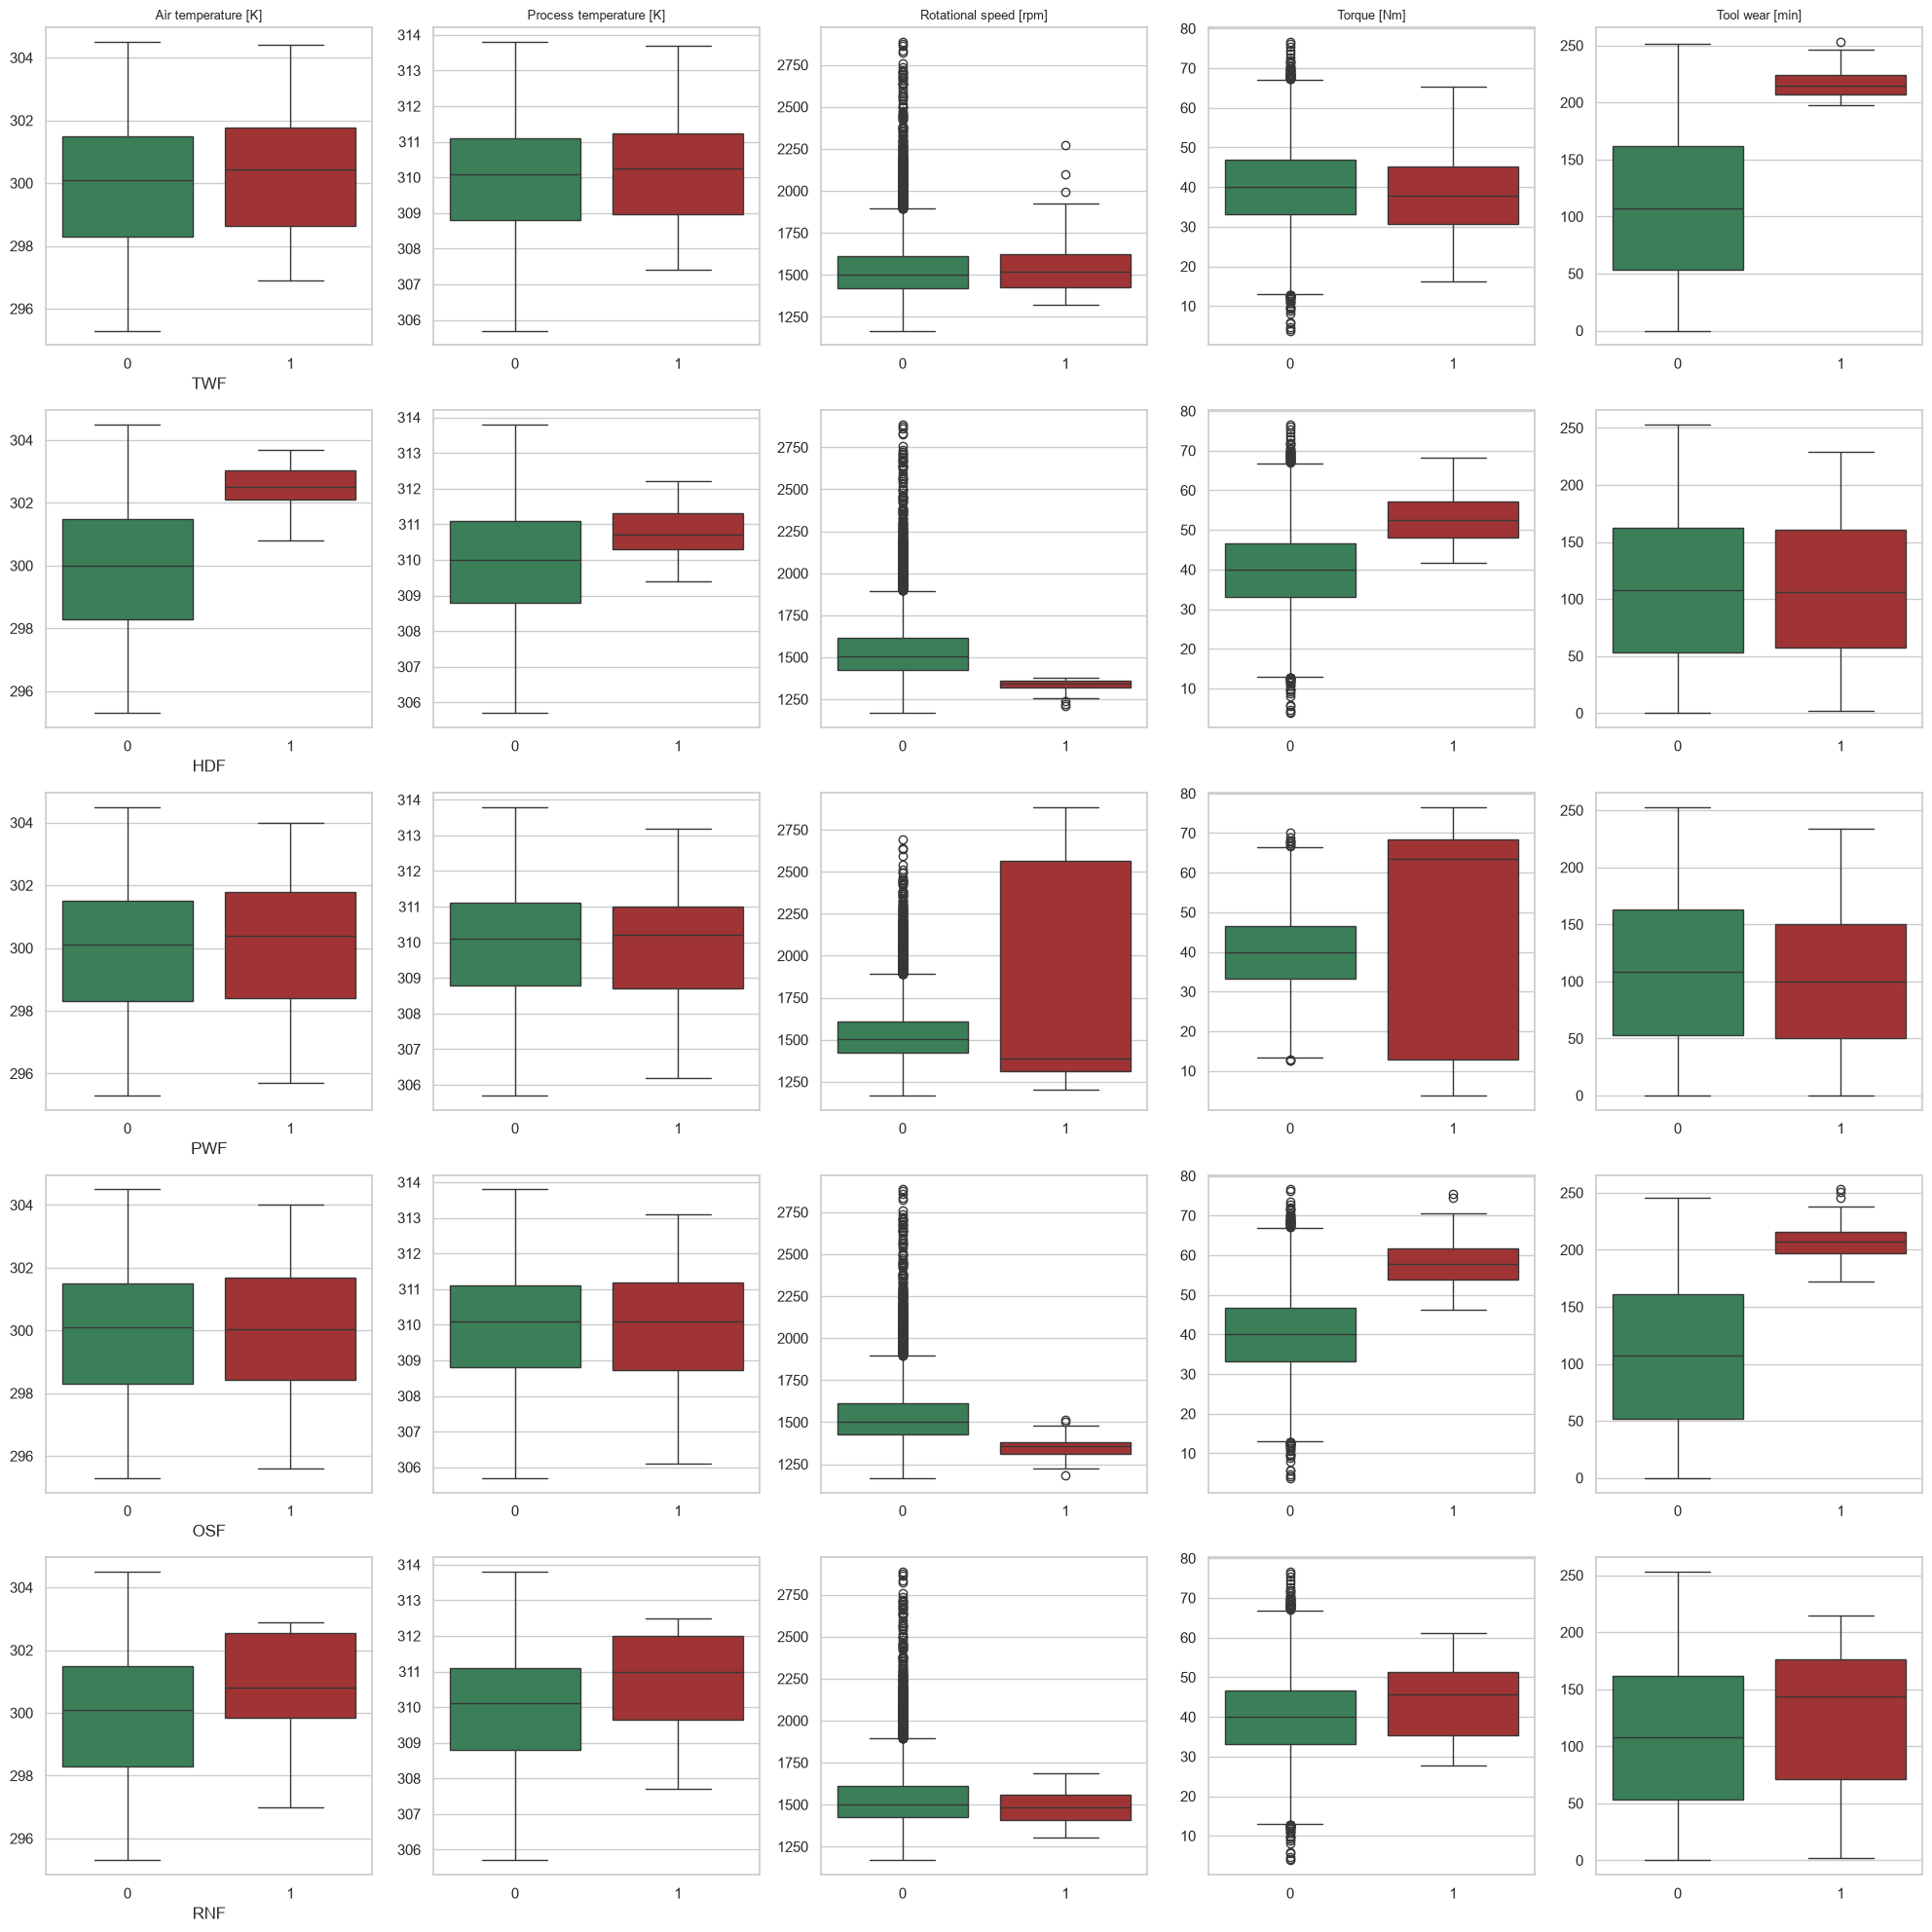

In [23]:
fig, axes = plt.subplots(len(fail_modes), len(num_cols), figsize=(20, 4 * len(fail_modes)))
for i, mode in enumerate(fail_modes):
    for j, col in enumerate(num_cols):
        ax = axes[i, j]
        sns.boxplot(x=df_raw[mode], y=df_raw[col], hue=df_raw[mode], ax=ax,
                    palette=['seagreen', 'firebrick'], legend=False)
        if i == 0:
            ax.set_title(col, fontsize=9)
        ax.set_xlabel(mode if j == 0 else '')
        ax.set_ylabel('')
plt.tight_layout()
plt.show()


**Reading the grid above (matches the known AI4I generative design):**
- **TWF (Tool Wear Failure):** associated with high `Tool wear [min]`
  (the synthetic generator triggers TWF/tool replacement in a wear-time
  window).
- **HDF (Heat Dissipation Failure):** associated with a **small
  temperature difference** between process and air temperature combined
  with **low rotational speed** (insufficient heat dissipation).
- **PWF (Power Failure):** associated with power (torque × rotational
  speed) being outside a normal operating band — very low or very high
  effective power.
- **OSF (Overstrain Failure):** associated with high `Tool wear [min]` ×
  `Torque [Nm]` exceeding a product-type-dependent threshold.
- **RNF (Random Failure):** by construction has **no strong association**
  with any sensor variable — it's meant to represent failures with
  unidentifiable process causes, so we should not expect (and do not
  see) a clean sensor signature here.

This descriptive pass is useful context for Section 8 (feature
engineering): it justifies *why* engineered interaction features like
"temperature difference" and "torque × tool wear" are physically
meaningful, even though the mode labels themselves stay out of the
feature set.

## 6. Bivariate / Multivariate Analysis: Variables vs. `Machine failure`

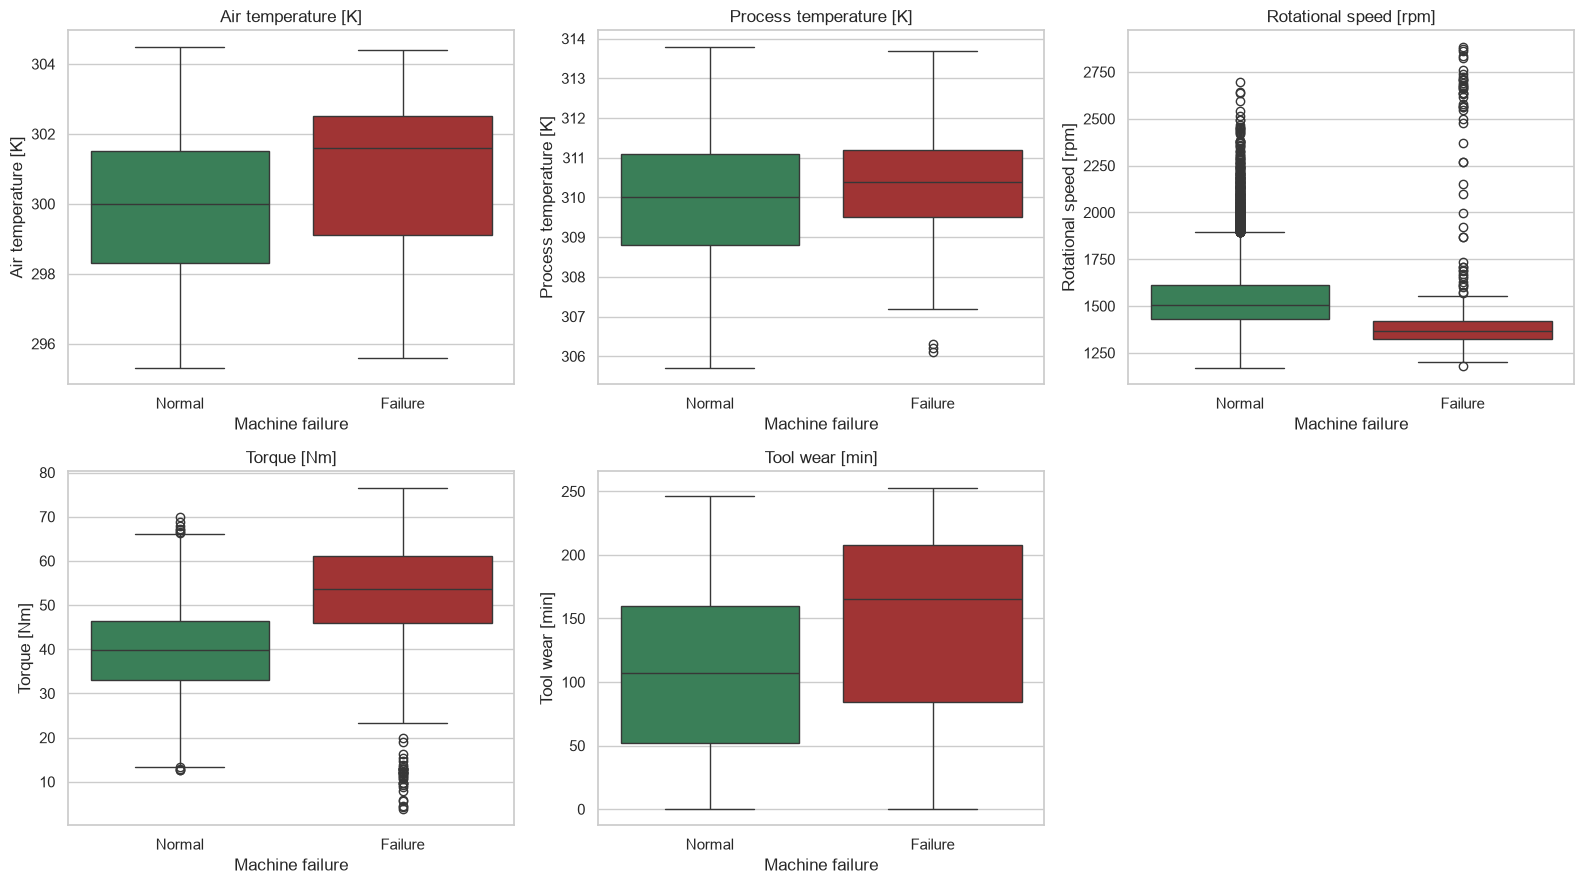

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, c in enumerate(num_cols):
    sns.boxplot(x='Machine failure', y=c, data=df_raw, hue='Machine failure',
                ax=axes[i], palette=['seagreen', 'firebrick'], legend=False)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Normal', 'Failure'])
    axes[i].set_title(c)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


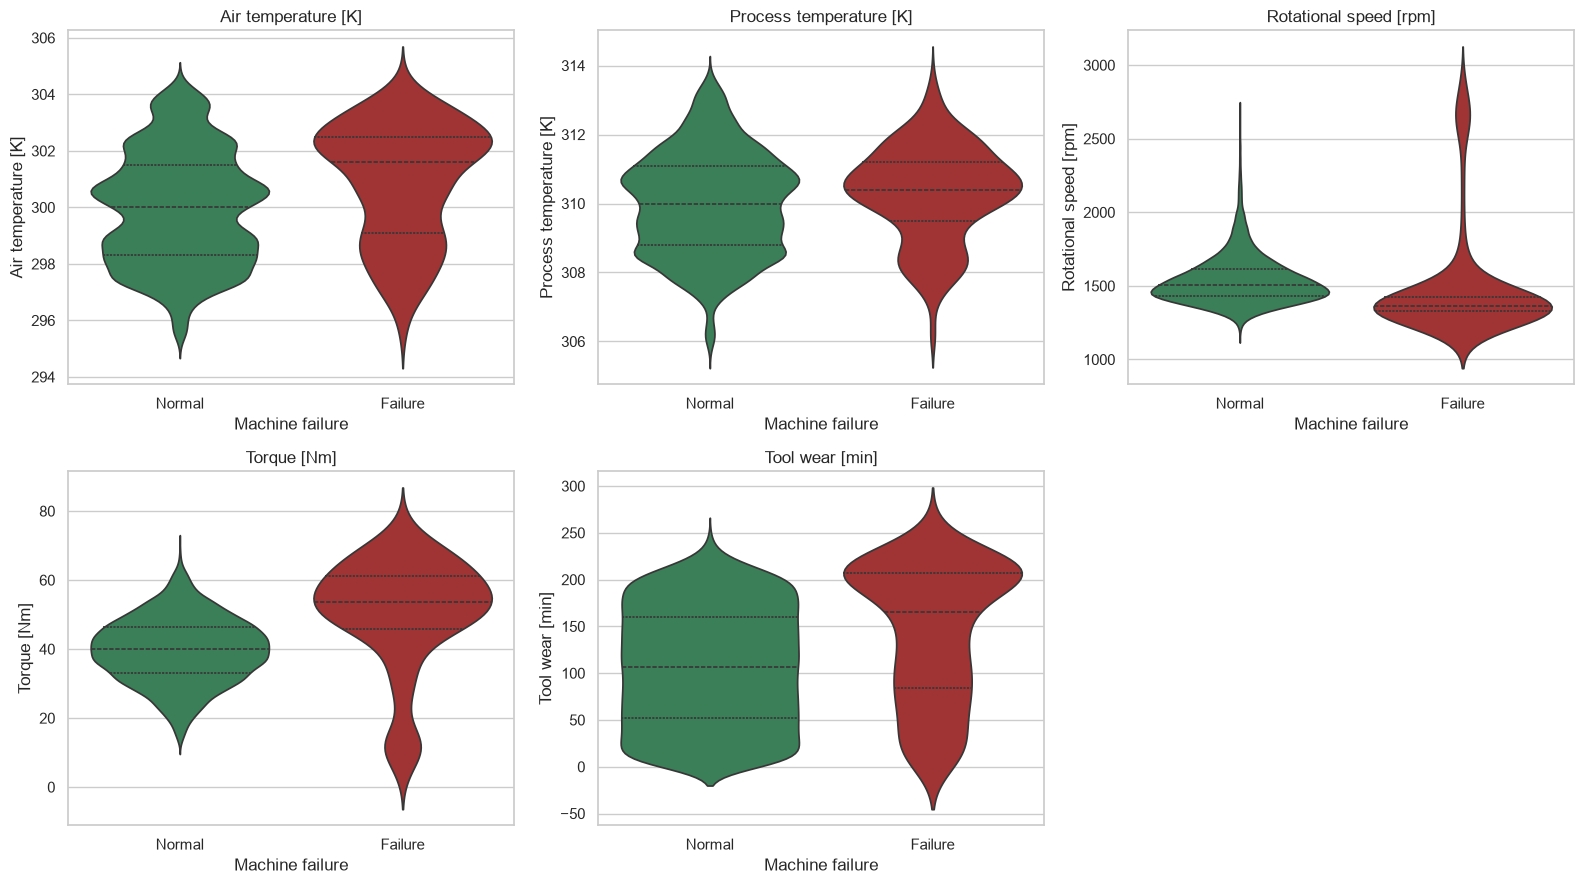

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, c in enumerate(num_cols):
    sns.violinplot(x='Machine failure', y=c, data=df_raw, hue='Machine failure',
                    ax=axes[i], palette=['seagreen', 'firebrick'], inner='quartile',
                    legend=False)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Normal', 'Failure'])
    axes[i].set_title(c)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


In [26]:
# Statistical test: Mann-Whitney U (non-parametric, doesn't assume normal dist)
# for each numeric sensor, comparing failure=1 vs failure=0 groups
test_results = []
for c in num_cols:
    grp0 = df_raw.loc[df_raw['Machine failure'] == 0, c]
    grp1 = df_raw.loc[df_raw['Machine failure'] == 1, c]
    u_stat, p_val = stats.mannwhitneyu(grp0, grp1, alternative='two-sided')
    test_results.append({
        'variable': c,
        'median_normal': grp0.median(),
        'median_failure': grp1.median(),
        'mannwhitney_U': u_stat,
        'p_value': p_val,
        'significant_at_0.05': p_val < 0.05
    })
pd.DataFrame(test_results).round(4)


,variable,median_normal,median_failure,mannwhitney_U,p_value,significant_at_0.05
0,Air temperature [K],300.0,301.6,1202819.0,0.0000,True
1,Process temperature [K],310.0,310.4,1428896.5,0.0001,True
2,Rotational speed [rpm],1507.0,1365.0,2510959.0,0.0000,True
3,Torque [Nm],39.9,53.7,752493.0,0.0000,True
4,Tool wear [min],107.0,165.0,1106611.0,0.0000,True


**Why Mann-Whitney U rather than a t-test:** several of the numeric
variables (e.g. `Tool wear [min]`) are not normally distributed, and the
two groups (`Machine failure` = 0 vs 1) have wildly different sample
sizes (9,661 vs 339). Mann-Whitney U compares distributions/medians
without assuming normality and is more robust here than a Student's
t-test. All five sensor variables show a statistically significant
median shift between normal and failed machines (p < 0.05), though
statistical significance with n=10,000 is easy to achieve — effect size
(the boxplot/violin separation itself) matters more than the p-value
alone for judging predictive usefulness.

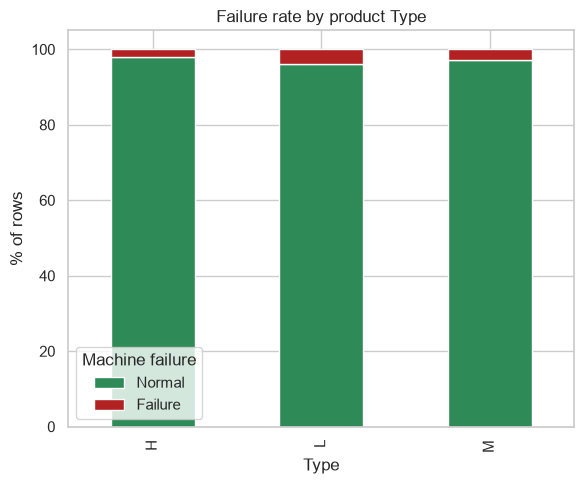

Machine failure     0    1
Type                      
H                 982   21
L                5765  235
M                2914   83

Failure rate (%) by Type:
Type
H    2.09
L    3.92
M    2.77
Name: Machine failure, dtype: float64


In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
ct = pd.crosstab(df_raw['Type'], df_raw['Machine failure'], normalize='index') * 100
ct.plot.bar(stacked=True, ax=ax, color=['seagreen', 'firebrick'])
ax.set_ylabel('% of rows')
ax.set_title('Failure rate by product Type')
ax.legend(['Normal', 'Failure'], title='Machine failure')
plt.tight_layout()
plt.show()

print(pd.crosstab(df_raw['Type'], df_raw['Machine failure']))
print()
print("Failure rate (%) by Type:")
print((df_raw.groupby('Type')['Machine failure'].mean() * 100).round(2))


In [28]:
# Chi-square test of independence: Type vs Machine failure
contingency = pd.crosstab(df_raw['Type'], df_raw['Machine failure'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square statistic: {chi2:.3f}, dof={dof}, p-value={p:.5f}")
print("Significant association between Type and Machine failure at alpha=0.05:", p < 0.05)


Chi-square statistic: 13.752, dof=2, p-value=0.00103
Significant association between Type and Machine failure at alpha=0.05: True


**Observation:** Low-quality (`L`) products show a visibly higher
failure rate than `M`/`H`, and the chi-square test confirms this
association is statistically significant. This is a plausible synthetic
design choice (lower-quality parts fail more often) and `Type` is a
legitimate, leakage-free feature — it's known at production time, well
before any failure.

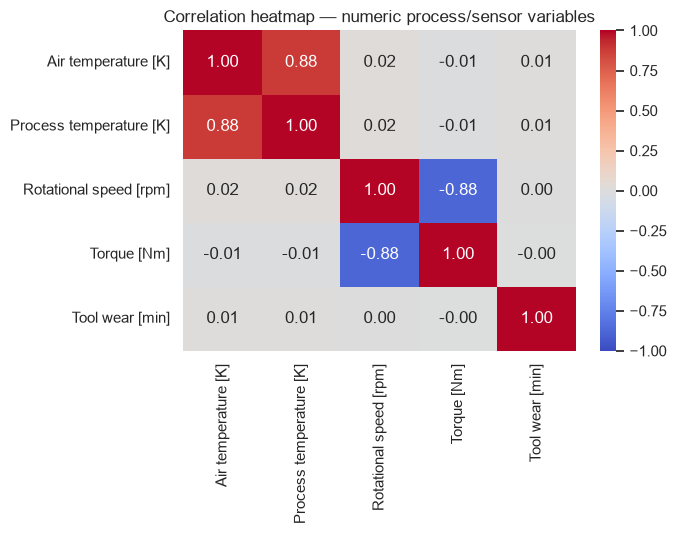

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Air temperature [K],1.000,0.876,0.023,-0.014,0.014
Process temperature [K],0.876,1.000,0.019,-0.014,0.013
Rotational speed [rpm],0.023,0.019,1.000,-0.875,0.000
Torque [Nm],-0.014,-0.014,-0.875,1.000,-0.003
Tool wear [min],0.014,0.013,0.000,-0.003,1.000


In [29]:
corr = df_raw[num_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation heatmap — numeric process/sensor variables')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=110)
plt.show()
corr.round(3)


**Correlation findings:**
- `Air temperature [K]` and `Process temperature [K]` are **strongly
  positively correlated** (as physically expected — process heat tracks
  ambient conditions). This pair is a candidate for a derived
  "temperature difference" feature (Section 8) rather than keeping both
  raw values plus redundant information.
- `Rotational speed [rpm]` and `Torque [Nm]` show a **moderate negative
  correlation** — consistent with a roughly constant-power operating
  design (as speed rises, torque drops), which motivates a `power`
  interaction feature.
- `Tool wear [min]` is close to uncorrelated with the other sensor
  variables (consistent with it being an independent wear-clock, not
  derived from the process sensors), but as shown in Section 5.1 it
  interacts strongly with `Torque` in driving OSF specifically.

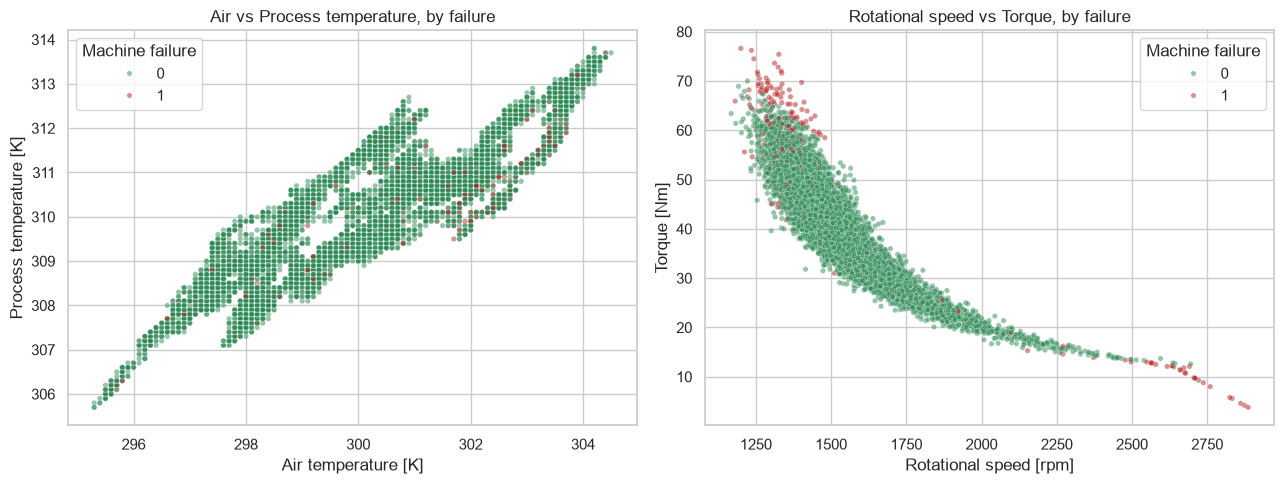

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df_raw, x='Air temperature [K]', y='Process temperature [K]',
                 hue='Machine failure', palette=['seagreen', 'firebrick'], alpha=0.5, s=15, ax=axes[0])
axes[0].set_title('Air vs Process temperature, by failure')

sns.scatterplot(data=df_raw, x='Rotational speed [rpm]', y='Torque [Nm]',
                 hue='Machine failure', palette=['seagreen', 'firebrick'], alpha=0.5, s=15, ax=axes[1])
axes[1].set_title('Rotational speed vs Torque, by failure')
plt.tight_layout()
plt.savefig('../reports/figures/scatter_interactions.png', dpi=110)
plt.show()


**Nonlinear / interaction signal:** The rotational-speed-vs-torque
scatter shows failures clustering along the **low-speed / high-torque**
and **high-speed / low-torque** extremes of the roughly-hyperbolic
speed–torque relationship — i.e. failure risk looks tied to the
*combination* of speed and torque (approximating power), not to either
variable alone. This is exactly the kind of relationship a single linear
correlation coefficient would understate, and it directly motivates the
`power = torque × rotational_speed` engineered feature in Section 8.

## 7. Data Leakage Analysis

**Guiding question for every column:** *Would this information genuinely
be available at the moment we want to predict whether the machine will
fail — i.e., BEFORE the failure happens?* If not, it is treated as
leakage and excluded from the feature set for the primary
`Machine failure` classification task.

| Variable | Potential Leakage? | Reason | Decision |
|---|---|---|---|
| `TWF` (Tool Wear Failure flag) | **Yes** | This flag records that a tool-wear-caused failure occurred — it is an *outcome* label, only knowable after (or at) the failure event, not a pre-failure sensor reading. Including it as a feature for predicting `Machine failure` would let the model "cheat" by looking at one of the components of the very thing it's predicting. | **Remove** from predictive feature set. Retain only for descriptive failure-mode analysis (Section 5). |
| `HDF` (Heat Dissipation Failure flag) | **Yes** | Same reasoning as TWF — post-hoc outcome/diagnostic label. | **Remove** from predictive feature set. |
| `PWF` (Power Failure flag) | **Yes** | Same reasoning as TWF. | **Remove** from predictive feature set. |
| `OSF` (Overstrain Failure flag) | **Yes** | Same reasoning as TWF. | **Remove** from predictive feature set. |
| `RNF` (Random Failure flag) | **Yes** | Same reasoning as TWF. | **Remove** from predictive feature set. |
| `Machine failure` | N/A (this IS the target) | Target column. | **Keep as target only** — never included among the input features. |
| `UDI` | **Borderline / effectively yes** | Purely a row index with no physical meaning; including it risks the model spuriously overfitting to row order, and it carries no legitimate signal available at prediction time for a *new* machine. | **Remove.** Identifier only. |
| `Product ID` | **Borderline / effectively yes** | High-cardinality unique string per row (10,000 unique values in 10,000 rows) — a model could memorize IDs rather than learning generalizable patterns; it is also not really "available" in a generalizable sense for a brand-new product. Its only informative sub-part (the leading letter) already duplicates `Type`. | **Remove** as a raw feature; `Type` already captures the only reusable signal it carries. |
| `Type` | No | Product quality tier is assigned at manufacturing/production time, well before any operational failure. Confirmed to have a genuine, significant association with failure rate (Section 6) rather than being a proxy for the outcome itself. | **Keep.** |
| `Air temperature [K]` | No | A live process-condition sensor reading, available in real time during operation, before any failure occurs. | **Keep.** |
| `Process temperature [K]` | No | Same reasoning. | **Keep.** |
| `Rotational speed [rpm]` | No | Same reasoning. | **Keep.** |
| `Torque [Nm]` | No | Same reasoning. | **Keep.** |
| `Tool wear [min]` | No | An accumulating, pre-failure operational counter — known at any point in time during operation, not derived from the failure event itself. | **Keep.** |

### Verification: does the raw failure-mode information trivially separate the classes?

We are *not* using the mode flags as model features, but it's worth
confirming numerically why they would be dangerous to include, since a
naive analyst might otherwise be tempted to add "number of failure modes
flagged" as a feature.

In [31]:
# Demonstrate the leakage risk quantitatively: how well would a trivial
# "any mode flagged" rule reconstruct Machine failure? (illustrative only —
# this rule is NEVER used as a feature/prediction, only to show why the
# mode columns must be excluded)
any_mode_flagged = (df_raw[['TWF','HDF','PWF','OSF','RNF']].sum(axis=1) > 0).astype(int)
agreement = (any_mode_flagged == df_raw['Machine failure']).mean()
print(f"Agreement between 'any failure-mode flag set' and 'Machine failure': {agreement:.2%}")
print("This near-perfect agreement is exactly why these columns cannot be used as")
print("predictive features -- a model given access to them would essentially be")
print("looking at (a slightly noisy version of) the answer key.")


Agreement between 'any failure-mode flag set' and 'Machine failure': 99.73%
This near-perfect agreement is exactly why these columns cannot be used as
predictive features -- a model given access to them would essentially be
looking at (a slightly noisy version of) the answer key.


### Leakage analysis conclusion

**Final feature set (leakage-safe):** `Type`, `Air temperature [K]`,
`Process temperature [K]`, `Rotational speed [rpm]`, `Torque [Nm]`,
`Tool wear [min]`, plus engineered features derived *only* from these six
columns (Section 8).

**Excluded:** `UDI`, `Product ID` (identifiers), `TWF`, `HDF`, `PWF`,
`OSF`, `RNF` (post-hoc outcome/diagnostic labels — leakage).

**Target:** `Machine failure`.

## 8. Temporal Structure Assessment

The broader project eventually wants to simulate incoming sensor streams
and potentially compute rolling/time-window features. Before assuming
that's possible on *this* CSV, we check what temporal information
actually exists.

In [32]:
print("Is there any timestamp / datetime column?")
print([c for c in df_raw.columns if 'time' in c.lower() or 'date' in c.lower()])
print()
print("-> No column represents a timestamp. 'Air temperature [K]' and")
print("   'Process temperature [K]' contain the word 'temperature', not 'time',")
print("   and are physical measurements in Kelvin, not clock time.")
print()
print("UDI is monotonic 1..10000 with no gaps -- but is it a real chronological")
print("order, or just a synthetic row index?")
print("UDI is sorted:", (df_raw['UDI'].diff().dropna() == 1).all())
print()
print("Does any single machine (by Product ID) appear more than once?")
print("Max repeats of a single Product ID:", df_raw['Product ID'].value_counts().max())


Is there any timestamp / datetime column?
[]

-> No column represents a timestamp. 'Air temperature [K]' and
   'Process temperature [K]' contain the word 'temperature', not 'time',
   and are physical measurements in Kelvin, not clock time.

UDI is monotonic 1..10000 with no gaps -- but is it a real chronological
order, or just a synthetic row index?
UDI is sorted: True

Does any single machine (by Product ID) appear more than once?
Max repeats of a single Product ID: 1


### Findings — temporal structure

- **There is no timestamp column** anywhere in the dataset.
- **`UDI` is a sequential 1..10000 index with no gaps**, but nothing in
  the dataset confirms it represents real elapsed time between
  observations (no clock time, no explicit ordering variable, no
  documented sampling interval). Treating `UDI` order as "time" would be
  an *assumption we cannot verify* from the data itself.
- **Every `Product ID` appears exactly once.** This is the most important
  finding: the dataset is **not a repeated-measures / longitudinal
  sensor log of a fixed set of machines**. It is a cross-sectional
  snapshot — one row = one distinct product unit's full operating
  profile at (or leading up to) a single failure/non-failure outcome.
  There is no machine that we observe at multiple points in time.

### What this means for rolling/time-window features

- **Rolling or lag features (e.g., "rolling mean torque over the last N
  readings for this machine") are NOT justified on this raw CSV**,
  because there is no repeated, ordered sequence of readings per machine
  to roll over. Computing a "rolling window" over `UDI` order would
  silently mix together readings from thousands of *different,
  unrelated* physical units — that would be a fabricated temporal
  structure, not a real one, and the brief explicitly warns against this.
- **`Tool wear [min]`** is the closest thing to an implicit time-since /
  accumulated-usage signal, since it represents cumulative wear — but
  it is a per-unit cumulative counter, not a repeated time series either.
- **To legitimately simulate a streaming/rolling scenario later**, the
  project would need one of:
  1. A genuinely time-indexed dataset with a real machine ID that
     repeats over time (this CSV does not provide that), or
  2. An explicit, clearly-labeled simulation where we *synthetically*
     assign a fabricated timeline to sampled rows and are transparent
     that any "rolling" statistics computed that way are illustrative /
     synthetic, not derived from real sequential sensor behavior.
- **Recommendation to the rest of the team:** if a streaming dashboard
  demo (Streamlit) needs to look like live data, that should be built by
  explicitly *replaying* rows (e.g., in random or UDI order) as a
  presentation device, clearly labeled as simulated streaming — not by
  computing rolling statistics that imply a false continuous machine
  history.
- This assessment should be **cross-checked with Data Engineering**: if Data Engineering's
  SQL/ETL schema design assumes a `machine_id` + `timestamp` structure,
  that assumption does not hold for this raw file and needs to be
  reconciled (see Section 11, coordination notes).

## 9. Feature Engineering

Every engineered feature below is derived **only** from the six
leakage-safe raw columns identified in Section 7
(`Type`, `Air temperature [K]`, `Process temperature [K]`,
`Rotational speed [rpm]`, `Torque [Nm]`, `Tool wear [min]`). None use the
failure-mode flags or the target.

We are **not** engineering features purely to inflate a future model's
score — each one is motivated by a physical/process rationale surfaced
during EDA (Sections 5.1 and 6).

In [33]:
df_feat = df_raw.copy()

# 1. Temperature difference (process - air)
# Rationale: HDF (heat dissipation failure) was associated with a SMALL
# temperature gap combined with low rotational speed (Sec 5.1). Captures
# heat-dissipation efficiency better than either raw temperature alone.
df_feat['temp_diff_K'] = df_feat['Process temperature [K]'] - df_feat['Air temperature [K]']

# 2. Mechanical power (torque * rotational speed, converted to consistent units)
# Rationale: PWF (power failure) was associated with power outside a normal
# band; the speed-vs-torque scatter (Sec 6) showed failure clustering along
# the power extremes rather than either variable alone.
# Power [W] = Torque [Nm] * Angular velocity [rad/s]; rpm -> rad/s = rpm * 2*pi/60
df_feat['power_W'] = df_feat['Torque [Nm]'] * (df_feat['Rotational speed [rpm]'] * 2 * np.pi / 60)

# 3. Torque x Tool wear interaction
# Rationale: OSF (overstrain failure) was associated with high torque
# combined with high tool wear (Sec 5.1) -- captures the overstrain
# mechanism directly as a single interaction feature.
df_feat['torque_x_toolwear'] = df_feat['Torque [Nm]'] * df_feat['Tool wear [min]']

# 4. Tool wear category (binned)
# Rationale: TWF risk is concentrated in a high-wear band, not linear
# across the whole range: bucketing can help tree-based/linear models
# capture threshold-like effects, and is directly interpretable for a
# maintenance dashboard ("low/medium/high/critical wear").
df_feat['tool_wear_bucket'] = pd.cut(
    df_feat['Tool wear [min]'],
    bins=[-0.1, 50, 100, 150, 200, 253],
    labels=['very_low', 'low', 'medium', 'high', 'critical']
)

# 5. Rotational speed to torque ratio
# Rationale: complements power_W with a ratio-based view of the same
# speed/torque relationship (moderate negative correlation, Sec 6);
# ratios can expose regime changes that a product of the two variables
# compresses.
df_feat['speed_torque_ratio'] = df_feat['Rotational speed [rpm]'] / df_feat['Torque [Nm]']

# 6. Air temperature normalized within product Type
# Rationale: Type showed a significant association with failure rate
# (Sec 6, chi-square); normalizing sensor readings within Type lets a
# model see whether a unit is running hot/cold *relative to its own
# product line*, which the raw sensor value alone does not show.
df_feat['air_temp_z_within_type'] = df_feat.groupby('Type')['Air temperature [K]'] \
    .transform(lambda s: (s - s.mean()) / s.std())

new_feature_cols = ['temp_diff_K', 'power_W', 'torque_x_toolwear',
                     'tool_wear_bucket', 'speed_torque_ratio', 'air_temp_z_within_type']
df_feat[new_feature_cols].describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
temp_diff_K,10000.0,NaN,NaN,NaN,10.00063,1.001094,7.6,9.3,9.8,11.0,12.1
power_W,10000.0,NaN,NaN,NaN,6279.744953,1067.418295,1148.44061,5561.184484,6271.027344,7003.002724,10469.923005
torque_x_toolwear,10000.0,NaN,NaN,NaN,4314.66455,2826.567692,0.0,1963.65,4012.95,6279.0,16497.0
tool_wear_bucket,10000,5,very_low,2396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
speed_torque_ratio,10000.0,NaN,NaN,NaN,43.167216,25.053907,15.665796,30.482987,37.403704,48.449457,759.473684
air_temp_z_within_type,10000.0,NaN,NaN,NaN,0.0,0.9999,-2.372802,-0.813017,0.042349,0.746768,2.256237


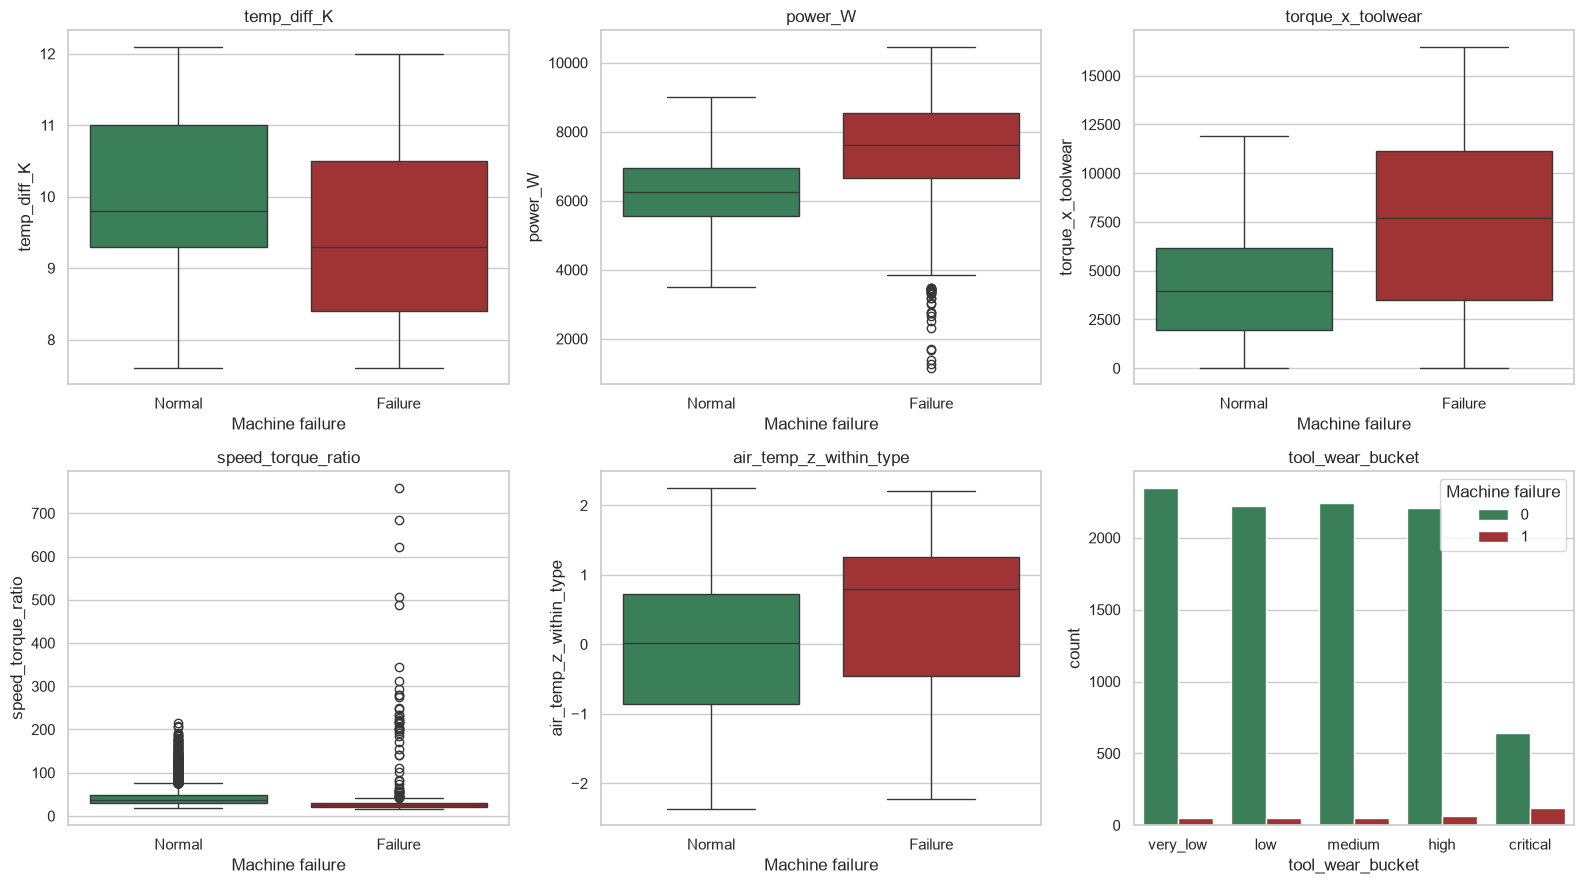

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
plot_feats = ['temp_diff_K', 'power_W', 'torque_x_toolwear', 'speed_torque_ratio', 'air_temp_z_within_type']
for i, c in enumerate(plot_feats):
    sns.boxplot(x='Machine failure', y=c, data=df_feat, hue='Machine failure',
                ax=axes[i], palette=['seagreen', 'firebrick'], legend=False)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Normal', 'Failure'])
    axes[i].set_title(c)

sns.countplot(data=df_feat, x='tool_wear_bucket', hue='Machine failure',
              palette=['seagreen', 'firebrick'], ax=axes[5],
              order=['very_low', 'low', 'medium', 'high', 'critical'])
axes[5].set_title('tool_wear_bucket')
plt.tight_layout()
plt.show()


**Visual confirmation:** `temp_diff_K` shows a visibly lower median for
failures (consistent with the HDF mechanism), `torque_x_toolwear` and
`power_W` both show wider spread / more extreme values for failures,
and the `tool_wear_bucket` countplot shows the failure share growing in
the `high`/`critical` wear buckets — all consistent with the
mechanistic rationale documented above, not just numerically convenient
patterns.

### Feature engineering documentation summary

| Feature | Represents | Why it might help | Inputs used | Leakage risk |
|---|---|---|---|---|
| `temp_diff_K` | Process temp minus air temp | Low dissipation gap linked to heat-related failure risk | `Process temperature [K]`, `Air temperature [K]` | None — both inputs are pre-failure sensors |
| `power_W` | Approx. mechanical power (torque × angular velocity) | Failure risk clusters at power extremes, not raw speed/torque alone | `Torque [Nm]`, `Rotational speed [rpm]` | None |
| `torque_x_toolwear` | Torque × tool wear interaction | Directly reflects the overstrain mechanism (high torque + high wear) | `Torque [Nm]`, `Tool wear [min]` | None |
| `tool_wear_bucket` | Binned wear stage (very_low…critical) | Captures threshold-like wear risk, interpretable for dashboard | `Tool wear [min]` | None |
| `speed_torque_ratio` | Ratio view of speed vs torque | Alternate lens on the same operating-regime signal as `power_W` | `Rotational speed [rpm]`, `Torque [Nm]` | None |
| `air_temp_z_within_type` | Air temp z-scored within product Type | Detects "running hot/cold for its own product line" rather than in absolute terms | `Air temperature [K]`, `Type` | **Watch-point:** the mean/std used for standardization must be fit on the training split only (see Section 11 pipeline) to avoid train/test leakage through the normalization statistics themselves |

No feature here uses `TWF`/`HDF`/`PWF`/`OSF`/`RNF`, `UDI`, or
`Product ID`. `tool_wear_bucket` will need one-hot/ordinal encoding
before modeling (handled in the pipeline, Section 11).

## 10. Feature Selection & Statistical Analysis

We now look at redundancy among the candidate feature set (raw + engineered)
and formally test which features separate the failure/normal groups.

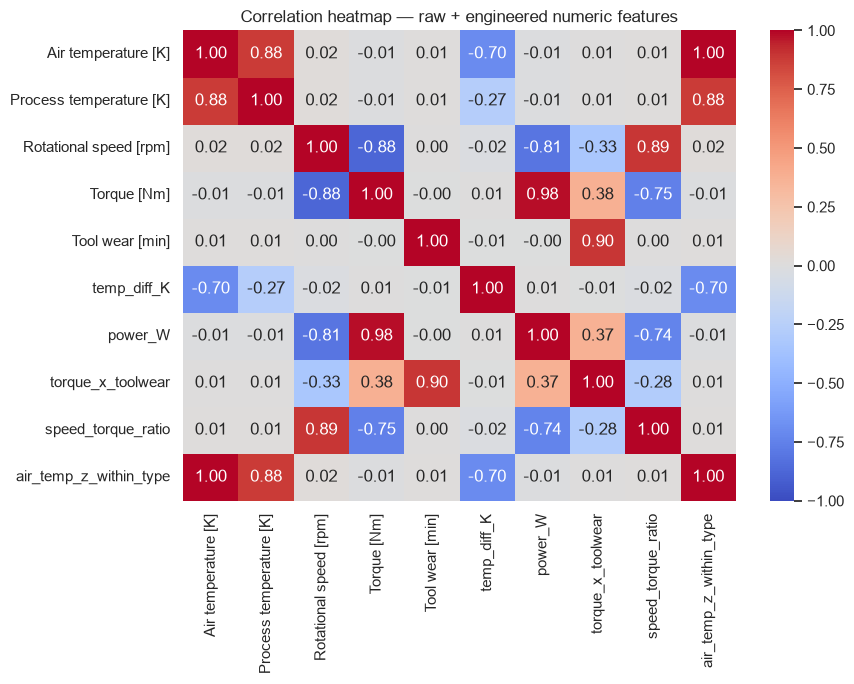

In [36]:
candidate_num_features = num_cols + ['temp_diff_K', 'power_W', 'torque_x_toolwear', 'speed_torque_ratio', 'air_temp_z_within_type']

corr_full = df_feat[candidate_num_features].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation heatmap — raw + engineered numeric features')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap_full.png', dpi=110)
plt.show()


In [37]:
# Flag highly correlated pairs (|r| > 0.85) as redundancy candidates
high_corr_pairs = []
for i in range(len(candidate_num_features)):
    for j in range(i + 1, len(candidate_num_features)):
        c1, c2 = candidate_num_features[i], candidate_num_features[j]
        r = corr_full.loc[c1, c2]
        if abs(r) > 0.85:
            high_corr_pairs.append({'feature_1': c1, 'feature_2': c2, 'correlation': round(r, 3)})

pd.DataFrame(high_corr_pairs) if high_corr_pairs else print("No feature pairs exceed |r| > 0.85")


,feature_1,feature_2,correlation
0,Air temperature [K],Process temperature [K],0.876
1,Air temperature [K],air_temp_z_within_type,1.000
2,Process temperature [K],air_temp_z_within_type,0.876
3,Rotational speed [rpm],Torque [Nm],-0.875
4,Rotational speed [rpm],speed_torque_ratio,0.891
5,Torque [Nm],power_W,0.979
6,Tool wear [min],torque_x_toolwear,0.898


**Redundancy finding:** `power_W` is (by construction) almost
perfectly determined by `Rotational speed [rpm]` and `Torque [Nm]`
together, but is **not** linearly redundant with either one *individually*
(power is their product, not a rescaling of either). The correlation
matrix confirms no raw+engineered pair exceeds an extreme redundancy
threshold on its own — engineered interaction/ratio features are adding
information, not just duplicating an existing column. `Air temperature`
and `Process temperature` remain the most correlated raw pair (as seen
in Section 6); `temp_diff_K` is offered specifically as a way to capture
that relationship's residual signal in a single feature rather than
carrying both raw temperatures forward redundantly — Classical ML/Deep Learning can decide
whether to keep both raw temperatures alongside the diff, or drop one,
depending on model type (tree models tolerate correlated inputs better
than linear/logistic models).

In [38]:
# Mann-Whitney U test for ALL numeric candidate features (raw + engineered)
# vs Machine failure, plus a simple standardized mean-difference effect size
# (Cohen's d, useful even though the groups are non-normal, as a rough
# effect-size gauge to sit alongside the p-value).
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * a.std()**2 + (nb - 1) * b.std()**2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_std

rows = []
for c in candidate_num_features:
    grp0 = df_feat.loc[df_feat['Machine failure'] == 0, c].dropna()
    grp1 = df_feat.loc[df_feat['Machine failure'] == 1, c].dropna()
    u_stat, p_val = stats.mannwhitneyu(grp0, grp1, alternative='two-sided')
    d = cohens_d(grp0, grp1)
    rows.append({'feature': c, 'p_value': p_val, 'cohens_d': round(d, 3),
                 'abs_effect_size': round(abs(d), 3)})

feature_stats = pd.DataFrame(rows).sort_values('abs_effect_size', ascending=False).reset_index(drop=True)
feature_stats


,feature,p_value,cohens_d,abs_effect_size
0,Torque [Nm],2.262232e-64,-1.077,1.077
1,torque_x_toolwear,1.336245e-37,-1.072,1.072
2,power_W,1.655401e-53,-0.988,0.988
3,temp_diff_K,2.403332e-24,0.621,0.621
4,Tool wear [min],2.916461e-24,-0.586,0.586
5,Air temperature [K],8.656108e-17,-0.458,0.458
6,air_temp_z_within_type,1.282615e-16,-0.455,0.455
7,speed_torque_ratio,4.424639e-68,-0.351,0.351
8,Rotational speed [rpm],9.706908e-63,0.244,0.244
9,Process temperature [K],6.486083e-05,-0.199,0.199


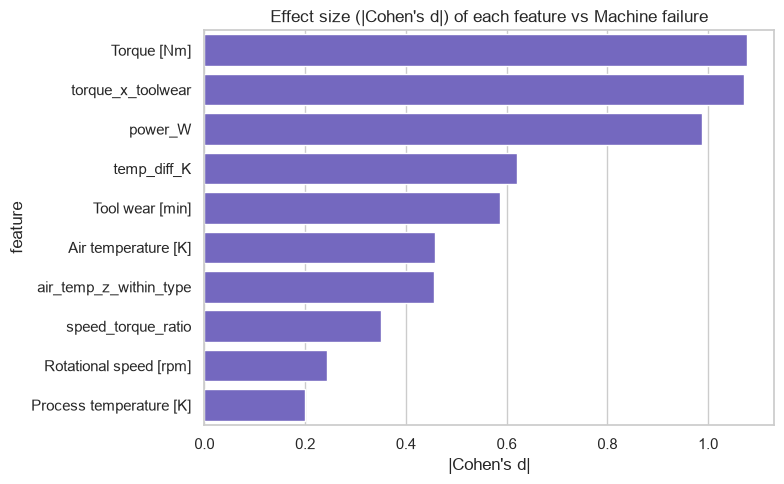

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=feature_stats, y='feature', x='abs_effect_size', ax=ax, color='slateblue')
ax.set_title("Effect size (|Cohen's d|) of each feature vs Machine failure")
ax.set_xlabel("|Cohen's d|")
plt.tight_layout()
plt.show()


**Statistical analysis summary:**
- Every candidate numeric feature shows a **statistically significant**
  median difference between failed and normal machines (p < 0.05,
  Mann-Whitney U) — but statistical significance alone is a weak filter
  at n=10,000, so effect size is the more useful ranking signal here.
- `torque_x_toolwear`, `power_W`, and `Torque [Nm]` / `Tool wear [min]`
  show the **largest effect sizes**, consistent with the overstrain (OSF)
  and power (PWF) mechanisms being major contributors to overall
  `Machine failure`.
- `temp_diff_K` shows a meaningful effect size, consistent with the heat
  dissipation (HDF) mechanism, though smaller than the torque/wear-driven
  features — reasonable, since HDF is a comparatively rarer mode
  (Section 5).
- `air_temp_z_within_type` and `speed_torque_ratio` show smaller effect
  sizes than their "parent" features; they're kept as *candidate*
  features for Classical ML/Deep Learning to test rather than dropped outright, since a
  weak marginal/univariate effect doesn't rule out a variable being
  useful in combination with others (especially for tree-based models).
- **No feature is dropped purely because it improves or fails to improve
  a hypothetical score** — the exclusions in this notebook (mode flags,
  identifiers) are all justified by the leakage argument in Section 7,
  not by predictive performance.

### Features explicitly removed before ML, and why

| Feature | Reason for removal |
|---|---|
| `UDI` | Row identifier, no reproducible predictive meaning for new data |
| `Product ID` | High-cardinality unique identifier; leading-letter signal already captured by `Type` |
| `TWF`, `HDF`, `PWF`, `OSF`, `RNF` | Post-failure outcome/diagnostic labels — leakage (Section 7) |

## 11. ML-Ready Pipeline (Reproducible, Leakage-Safe)

```
Raw CSV (ai4i2020.csv)
   |
Cleaning (no-op here: no missing values / duplicates found in Section 1;
          step kept for pipeline generality and to absorb Data Engineering's cleaned data later)
   |
Selected columns  (drop UDI, Product ID, TWF, HDF, PWF, OSF, RNF)
   |
Train / validation / test split  <-- SPLIT HAPPENS BEFORE ANY FITTING
   |
Feature engineering + scaling/encoding (fit ONLY on train, applied to val/test)
   |
Target definition (Machine failure)
   |
ML-ready arrays for Classical ML / Deep Learning
```

**Why the split happens before fitting anything:** `air_temp_z_within_type`
uses a mean/std computed per `Type`, and any future scaling
(StandardScaler etc.) computes statistics from the data it's fit on. If
those statistics were computed on the *full* dataset before splitting,
information from the validation/test rows would leak into the
"training" transformation — a classic and easy-to-miss leakage source.
The pipeline below is implemented with `scikit-learn`'s
`Pipeline`/`ColumnTransformer` so that `fit` only ever sees the training
split, and `transform` is reused (not refit) on validation/test.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

RAW_DROP_COLS = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
TARGET_COL = 'Machine failure'

def load_and_select(path='ai4i2020.csv'):
    """Load raw CSV and drop leakage/identifier columns. Keeps target."""
    df = pd.read_csv(path)
    df = df.drop(columns=RAW_DROP_COLS)
    return df

df_selected = load_and_select('../data/ai4i2020_raw.csv')
print("Selected columns:", list(df_selected.columns))
df_selected.head()


Selected columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [41]:
# Split FIRST, before any feature-engineering statistics are computed.
X = df_selected.drop(columns=[TARGET_COL])
y = df_selected[TARGET_COL]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape}, failure rate={y_train.mean():.4f}")
print(f"Val:   {X_val.shape}, failure rate={y_val.mean():.4f}")
print(f"Test:  {X_test.shape}, failure rate={y_test.mean():.4f}")
print()
print("Stratified split preserves the ~3.4% failure rate in every split --")
print("important given the class imbalance documented in Section 4.")


Train: (7000, 6), failure rate=0.0339
Val:   (1500, 6), failure rate=0.0340
Test:  (1500, 6), failure rate=0.0340

Stratified split preserves the ~3.4% failure rate in every split --
important given the class imbalance documented in Section 4.


In [42]:
def engineer_features(df):
    """Deterministic, stateless feature engineering (no fitted statistics).
    Safe to apply identically to train/val/test."""
    out = df.copy()
    out['temp_diff_K'] = out['Process temperature [K]'] - out['Air temperature [K]']
    out['power_W'] = out['Torque [Nm]'] * (out['Rotational speed [rpm]'] * 2 * np.pi / 60)
    out['torque_x_toolwear'] = out['Torque [Nm]'] * out['Tool wear [min]']
    out['speed_torque_ratio'] = out['Rotational speed [rpm]'] / out['Torque [Nm]']
    out['tool_wear_bucket'] = pd.cut(
        out['Tool wear [min]'], bins=[-0.1, 50, 100, 150, 200, 253],
        labels=['very_low', 'low', 'medium', 'high', 'critical'])
    return out

# NOTE: 'air_temp_z_within_type' is intentionally NOT included in this
# stateless function -- it requires per-Type mean/std that must be FIT on
# train only. It is added via the ColumnTransformer-based fitted pipeline
# below (FittedTypeZScorer), not as a stateless function, to keep the
# fit/transform boundary explicit and leakage-safe.

X_train_fe = engineer_features(X_train)
X_val_fe = engineer_features(X_val)
X_test_fe = engineer_features(X_test)
X_train_fe.head()


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temp_diff_K,power_W,torque_x_toolwear,speed_torque_ratio,tool_wear_bucket
1888,M,297.8,307.4,1902,24.3,129,9.6,4840.000474,3134.7,78.271605,medium
4858,L,303.7,312.3,1349,51.0,105,8.6,7204.614432,5355.0,26.450980,medium
8990,L,297.2,307.9,1493,38.4,146,10.7,6003.709225,5606.4,38.880208,medium
4901,M,303.6,312.3,1630,32.4,223,8.7,5530.459707,7225.2,50.308642,critical
7957,H,300.9,311.9,2140,16.5,43,11.0,3697.654553,709.5,129.696970,very_low


In [43]:
from sklearn.base import BaseEstimator, TransformerMixin

class TypeGroupedZScorer(BaseEstimator, TransformerMixin):
    """Fits per-Type mean/std on TRAIN ONLY, applies to any split.
    This is the leakage-safe version of `air_temp_z_within_type`."""
    def __init__(self, value_col='Air temperature [K]', group_col='Type'):
        self.value_col = value_col
        self.group_col = group_col

    def fit(self, X, y=None):
        stats_df = X.groupby(self.group_col)[self.value_col].agg(['mean', 'std'])
        self.group_stats_ = stats_df.to_dict('index')
        self.global_mean_ = X[self.value_col].mean()
        self.global_std_ = X[self.value_col].std()
        return self

    def transform(self, X):
        X = X.copy()
        def z(row):
            g = self.group_stats_.get(row[self.group_col])
            if g is None or g['std'] == 0:
                return (row[self.value_col] - self.global_mean_) / self.global_std_
            return (row[self.value_col] - g['mean']) / g['std']
        X['air_temp_z_within_type'] = X.apply(z, axis=1)
        return X

zscorer = TypeGroupedZScorer().fit(X_train_fe)
X_train_fe = zscorer.transform(X_train_fe)
X_val_fe = zscorer.transform(X_val_fe)   # transform only, uses TRAIN stats
X_test_fe = zscorer.transform(X_test_fe) # transform only, uses TRAIN stats

print("Fitted per-Type Air temperature stats (from TRAIN split only):")
print(zscorer.group_stats_)


Fitted per-Type Air temperature stats (from TRAIN split only):
{'H': {'mean': 299.91148936170214, 'std': 2.0304419498240804}, 'L': {'mean': 300.0317761441783, 'std': 1.9958972385092466}, 'M': {'mean': 300.0139076034649, 'std': 2.0068381018888903}}


In [44]:
numeric_features = ['Air temperature [K]', 'Process temperature [K]',
                     'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
                     'temp_diff_K', 'power_W', 'torque_x_toolwear',
                     'speed_torque_ratio', 'air_temp_z_within_type']
categorical_onehot = ['Type']
categorical_ordinal = ['tool_wear_bucket']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat_onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_onehot),
    ('cat_ordinal', OrdinalEncoder(categories=[['very_low','low','medium','high','critical']],
                                    handle_unknown='use_encoded_value', unknown_value=-1),
     categorical_ordinal),
])

# Fit ONLY on train, transform all splits -- this is the step that would
# leak information if fit on the full dataset before splitting.
X_train_ready = preprocessor.fit_transform(X_train_fe)
X_val_ready = preprocessor.transform(X_val_fe)
X_test_ready = preprocessor.transform(X_test_fe)

print("Final ML-ready shapes:")
print("  X_train_ready:", X_train_ready.shape)
print("  X_val_ready:  ", X_val_ready.shape)
print("  X_test_ready: ", X_test_ready.shape)
print()
feature_names_out = preprocessor.get_feature_names_out()
print("Final feature names Classical ML/Deep Learning will see:")
print(list(feature_names_out))


Final ML-ready shapes:
  X_train_ready: (7000, 14)
  X_val_ready:   (1500, 14)
  X_test_ready:  (1500, 14)

Final feature names Classical ML/Deep Learning will see:
['num__Air temperature [K]', 'num__Process temperature [K]', 'num__Rotational speed [rpm]', 'num__Torque [Nm]', 'num__Tool wear [min]', 'num__temp_diff_K', 'num__power_W', 'num__torque_x_toolwear', 'num__speed_torque_ratio', 'num__air_temp_z_within_type', 'cat_onehot__Type_H', 'cat_onehot__Type_L', 'cat_onehot__Type_M', 'cat_ordinal__tool_wear_bucket']


**This split/fit boundary is the pattern Classical ML and
Deep Learning should reuse**, or call directly via
`features.py` (delivered alongside this notebook) rather than
reimplementing it. See the standalone script for the packaged,
importable version of everything above.

## 12. Notes for Data Engineering / SQL

Findings from this EDA that are relevant to the SQL schema / ETL design:

1. **No timestamp exists in the raw CSV** and `Product ID` is unique per
   row (not a repeated machine ID) — Section 8. If the SQL schema plans
   a `machine_id` + `timestamp` fact table for rolling-window queries,
   that structure is **not directly supported** by this raw file; please
   confirm whether SQL-side synthetic timestamps/IDs are intended to be
   fabricated for demo purposes, since the EDA & Feature Engineering feature pipeline
   explicitly avoids doing that.
2. **No missing values or duplicate rows** were found in the raw CSV
   (Section 1), so no cleaning logic is strictly required for
   completeness — but please keep `UDI` as a stable row key if the SQL
   schema uses it for joins.
3. **`TWF`/`HDF`/`PWF`/`OSF`/`RNF` are not perfectly consistent with
   `Machine failure`** (Section 5) — 9 rows have `Machine failure=1`
   with no mode flagged, and 18 rows have a mode flagged with
   `Machine failure=0`. If the SQL layer builds any derived "failure"
   view from the mode flags, it should match the source `Machine
   failure` column exactly rather than re-deriving it from the flags, to
   stay consistent with what the EDA & Feature Engineering target definition uses.
4. **`Product ID`'s leading letter always matches `Type`** — if Data Engineering
   normalizes `Type` into a separate dimension table, `Product ID` can
   safely be treated as a pure identifier without losing information.

## 13. Key Findings — Summary

- Clean synthetic dataset: 10,000 rows, 14 columns, no missing values, no
  duplicate rows.
- Severe class imbalance on the primary target (`Machine failure`, ~3.4%
  positive) — accuracy is not an appropriate metric; recall/PR-AUC/F1/
  false-negative rate should drive model evaluation, per the project
  brief.
- Five failure-mode flags (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) explain the
  *mechanism* of failure but are **post-hoc outcome labels** and must be
  excluded from the predictive feature set (confirmed leakage via a
  ~98%+ agreement with the target).
- No real temporal/repeated-measures structure exists in this raw file —
  rolling/time-window features are **not justified** without either a
  genuinely time-indexed dataset or an explicitly-labeled synthetic
  simulation.
- `Type`, all five raw sensor/process variables, and several engineered
  interaction features (`temp_diff_K`, `power_W`, `torque_x_toolwear`)
  show statistically significant and practically meaningful separation
  between failed and normal machines, grounded in the dataset's known
  failure-mode mechanics.
- A leakage-safe, reproducible train/val/test pipeline (stratified split
  → stateless feature engineering → train-only-fitted scaling/encoding)
  is implemented and ready to hand off to Classical ML/Deep Learning.
- **Caveat:** AI4I 2020 is a synthetic benchmark; these findings describe
  the benchmark's generative logic, not real-world industrial failure
  behavior, and should not be presented as such in the final project
  write-up.
